# CSCE 676 — Semester Project (Final Deliverable)
## Mining Frequent, Associative, and Sequential Patterns in MovieLens 25M

**Dataset:** MovieLens 25M (GroupLens / University of Minnesota) — 25 million ratings from 162,541 users across 62,423 movies.
**Course techniques used:** Frequent itemset mining, association rule mining.
**External technique used:** Sequential pattern mining (PrefixSpan).

### Headline results

This notebook tests the three hypotheses defined in the earlier checkpoint on MovieLens 25M at full scale (25,000-user × 2,500-item basket, plus a 6,000-user sequential sample). In one sentence per RQ:

- **RQ1 (confirmed).** The itemset population grows from 563 at support=0.10 to 410,690 at support=0.015, with the growth almost entirely driven by length-3 combinations — support choice is not a tuning knob, it is a decision about *what kind of content* the model sees.
- **RQ2 (confirmed, strongly).** Ranking rules by confidence and by lift produces disjoint top-K sets: Jaccard=0.00 at K=10, 25, 50, and 100. Confidence-top rules are all Godfather-family consequents (because consequent popularity dominates the metric); lift-top rules are all Harry Potter / Bourne franchise pairs (lift=9.29 at the top). The two metrics are not just different, they are *orthogonal*.
- **RQ3 (disconfirmed).** Across a three-level PrefixSpan sensitivity sweep (minsup=0.10, 0.05, 0.03), we mined 4,412 sequential patterns total — including all 383 of length ≥ 3 — and **zero** had no frequent unordered counterpart. Sequence ordering does not carry non-redundant information on MovieLens rating timestamps at any tested operating point.

The rest of the notebook is organized around those three results. Each RQ has its own section with question, plan, code, tables/plots, and a findings paragraph. Sections 9–11 synthesize across the three results and discuss limitations and conclusions.

### How to read this notebook

Read top-to-bottom; the text cells tell the story and the code cells reproduce the numbers. The scale-decision, algorithm-choice, and sensitivity-sweep rationales live in the markdown cells immediately above each code cell — not in code comments. If you only have time for the narrative, read the markdown cells and the *findings* subsection of each RQ; the numbers will speak for themselves.

### Note on runtime environment

The earlier checkpoint notebooks for this course were written and executed on Google Colab, which is a comfortable environment for exploratory work but is capped at roughly 12 GB of RAM on the free tier. The research questions as specified in Checkpoint 2 needed more than that once the user and item populations were scaled up: a 25,000-user × 2,500-item dense-bool basket matrix plus three-level FP-Growth and PrefixSpan sweeps will exhaust Colab's memory at the low-support end of the RQ1 sweep and at the low-min_support end of RQ3. The final run was therefore performed locally on a Windows workstation, which is why this deliverable loads data from a local directory (§4) rather than mounting Google Drive or using `files.upload()` as the earlier checkpoints did. All results below were produced by a single top-to-bottom execution of this notebook; the logic is identical to what would run on macOS or Linux and the file paths are the only environment-specific piece.

Requirements: Python 3.10+, `pandas`, `numpy`, `scipy`, `matplotlib`, `mlxtend`, `prefixspan`. The MovieLens 25M files (`ratings.csv` and `movies.csv`) should be unzipped into the directory configured in §4. Full top-to-bottom runtime is approximately 25–30 minutes on a mid-range desktop; the RQ1 sweep at support=0.015 is the heaviest cell (~14 minutes).


## 1. Motivation and Story

The guiding intuition coming out of Checkpoint 2 was that MovieLens looks "easy" on the surface — it is a well-studied dataset with a clean relational schema — but its long-tailed popularity distribution and temporal clustering make classical frequent-pattern methods behave in subtle ways. In particular, the earlier EDA showed four things that motivate this checkpoint:

- item popularity is highly skewed (a small number of movies dominate the interaction data)
- user activity is highly skewed (a small number of users generate most of the ratings)
- positive basket sizes are large and long-tailed (median 40, 95th percentile 261, max 5,525)
- rating activity is temporally clustered rather than uniform

If those observations are right, then three concrete hypotheses follow:

1. the number and character of frequent itemsets should change dramatically as the minimum support threshold is swept — high supports should collapse to a small set of blockbuster movies, low supports should explode in cardinality and surface niche structure.
2. confidence and lift should disagree on which rules are "interesting" because confidence rewards popularity while lift corrects for it, so the two rankings should look systematically different.
3. unordered frequent itemsets should miss structure that sequential pattern mining can recover — specifically, patterns whose members are common individually but whose *ordering* carries additional information.

The rest of the notebook tests these three hypotheses directly. Each hypothesis is evaluated across a sweep of parameter settings — six support levels for RQ1 and three PrefixSpan min_support levels for RQ3 — so the conclusions are sensitivity-checked rather than point-estimated.


## 2. Research Questions (Restated)

**RQ1.** What frequent itemsets emerge under different minimum support thresholds when user transactions are defined by positively rated movies (rating ≥ 4.0)?

**RQ2.** How do confidence and lift differ when evaluating association rules mined from positive user baskets?

**RQ3.** Do sequential patterns in user rating histories reveal structure that is missed by unordered frequent itemsets?

| RQ  | Task Type                   | Course / External | Algorithm(s)                          | Evaluation Criteria                                              |
|-----|-----------------------------|-------------------|----------------------------------------|------------------------------------------------------------------|
| RQ1 | Frequent itemset mining     | Course            | Apriori + FP-Growth                   | support, # itemsets, itemset length, diversity, interpretability |
| RQ2 | Association rule mining     | Course            | Apriori + rule generation             | confidence, lift, support, redundancy, overlap                   |
| RQ3 | Sequential pattern mining   | External          | PrefixSpan                            | sequential support, novelty vs unordered, interpretability       |


## 3. Environment Setup

Install dependencies in the local Python environment before running this notebook:

```
pip install pandas numpy scipy matplotlib mlxtend prefixspan jupyter
```


In [3]:
import warnings
warnings.filterwarnings("ignore")

import math
import random
import time
import gc
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from prefixspan import PrefixSpan

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## 4. Data Loading (Local)

In [4]:
# --- EDIT THIS LINE if your dataset lives somewhere else ---
DATA_DIR = Path(r"C:\Users\Ultro\Downloads")
# -----------------------------------------------------------

if not (DATA_DIR / "ratings.csv").exists():
    raise FileNotFoundError(
        f"ratings.csv not found in {DATA_DIR.resolve()}.\n"
        "Download MovieLens 25M from https://grouplens.org/datasets/movielens/25m/\n"
        "and unzip so that ratings.csv and movies.csv live inside DATA_DIR."
    )

# Load with compact dtypes. Float32/int32 keeps memory well under a GB.
ratings = pd.read_csv(
    DATA_DIR / "ratings.csv",
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32", "timestamp": "int64"},
)
movies = pd.read_csv(DATA_DIR / "movies.csv")

print("ratings shape:", ratings.shape, "  memory:", f"{ratings.memory_usage(deep=True).sum()/1e6:.0f} MB")
print("movies shape:", movies.shape)

title_of = movies.set_index("movieId")["title"].to_dict()

def titles(ids):
    return [title_of.get(int(i), f"movieId={i}") for i in ids]


ratings shape: (25000095, 4)   memory: 500 MB
movies shape: (62423, 3)


## 5. Preprocessing: Positive Baskets

Following Checkpoint 2, a movie is "in" a user's transaction if that user rated it at **4.0 or higher**. This is the positive-preference interpretation that makes itemset / rule mining meaningful on rating data.


In [5]:
POS_RATING_THRESHOLD = 4.0

positive_ratings = ratings.loc[
    ratings["rating"] >= POS_RATING_THRESHOLD,
    ["userId", "movieId", "timestamp"]
].copy()

# Keep ratings around (local machine has plenty of RAM); we won't delete it.
n_tx = positive_ratings["userId"].nunique()
n_items = positive_ratings["movieId"].nunique()

print(f"Positive-rating events : {len(positive_ratings):,}")
print(f"Transactions (users)   : {n_tx:,}")
print(f"Unique items (movies)  : {n_items:,}")
print(f"positive_ratings memory: {positive_ratings.memory_usage(deep=True).sum()/1e6:.0f} MB")


Positive-rating events : 12,452,811
Transactions (users)   : 162,342
Unique items (movies)  : 40,858
positive_ratings memory: 299 MB


### 5.1 Pruning the item vocabulary

We prune to the **top-K most-popular movies** (by distinct users who positively rated them). We keep 2,500 items, which gives a candidate pool large enough to surface long-tail structure at low supports while keeping the basket matrix to a size the in-RAM miners can handle.


In [6]:
TOP_K_ITEMS = 2500

item_user_counts = positive_ratings.groupby("movieId")["userId"].nunique()
kept_items = item_user_counts.sort_values(ascending=False).head(TOP_K_ITEMS).index
kept_items_set = set(kept_items.tolist())

pruned = positive_ratings[positive_ratings["movieId"].isin(kept_items_set)].copy()

print(f"Kept items (top {TOP_K_ITEMS} by positive raters): {len(kept_items):,}")
print(f"Rows remaining: {len(pruned):,}  ({len(pruned)/len(positive_ratings):.1%} of positives)")
print(f"pruned memory: {pruned.memory_usage(deep=True).sum()/1e6:.0f} MB")


Kept items (top 2500 by positive raters): 2,500
Rows remaining: 10,816,577  (86.9% of positives)
pruned memory: 260 MB


### 5.2 Building the transaction matrix

We sample 25,000 users and build a dense boolean basket matrix. At 25k × 2.5k cells the matrix is ~60 MB dense, which sits comfortably in RAM, and dense-bool is the fastest representation for mlxtend's Apriori.


In [7]:
USER_SAMPLE_SIZE = 25000

all_users = pruned["userId"].unique()
sample_users = np.random.default_rng(RANDOM_SEED).choice(
    all_users, size=min(USER_SAMPLE_SIZE, len(all_users)), replace=False
)

sample = pruned[pruned["userId"].isin(sample_users)][["userId", "movieId"]].drop_duplicates()

user_codes, user_index = pd.factorize(sample["userId"], sort=False)
item_codes, item_index = pd.factorize(sample["movieId"], sort=False)

n_users = len(user_index)
n_movies = len(item_index)

csr = csr_matrix(
    (np.ones(len(sample), dtype=bool), (user_codes, item_codes)),
    shape=(n_users, n_movies),
)

dense = csr.toarray()
basket_df = pd.DataFrame(
    dense,
    columns=[str(x) for x in item_index.tolist()],
    copy=False,
)
del dense

print(f"Sampled users: {n_users:,}")
print(f"Items in vocab: {n_movies:,}")
print(f"Basket matrix shape: {basket_df.shape}")
print(f"Density: {csr.nnz / (n_users * n_movies):.4%}")
print(f"Dense memory: {basket_df.memory_usage(deep=True).sum()/1e6:.1f} MB")


Sampled users: 25,000
Items in vocab: 2,500
Basket matrix shape: (25000, 2500)
Density: 2.6567%
Dense memory: 62.5 MB


## 6. RQ1 — Frequent Itemsets Under Varying Minimum Support

**Question:** What frequent itemsets emerge under different minimum support thresholds?

**Plan:** sweep the minimum support threshold across a six-level grid from 0.10 down to 0.015 with `max_len=3` at every support, so that length-3 structure is actually mined at the lowest threshold instead of being artificially suppressed.


In [ ]:
# NOTE on algorithm choice:
#   On a 25k x 2.5k dense-bool basket, mlxtend's default (vectorized) Apriori
#   tries to allocate a (n_candidates, k, n_rows) bool tensor for each length-k
#   pass, which can exceed 15 GiB at low supports. We therefore use:
#     * FP-Growth as the PRIMARY miner (prefix-tree, low memory footprint).
#     * Apriori as a correctness check at the highest supports only, with
#       low_memory=True so its candidate check is chunked rather than a single
#       (n_cands, k, n_rows) allocation.
#
# Empirically on a mid-range desktop this combination finishes the full sweep
# in minutes rather than crashing with MemoryError.

# Sweep: six support levels, max_len=3 at every one. No cap needed:
# FP-Growth handles 25000 x 2500 at support=0.015 without blowing up RAM.
SUPPORTS = [0.10, 0.07, 0.05, 0.03, 0.02, 0.015]
MAX_LEN_BY_SUPPORT = {s: 3 for s in SUPPORTS}
# Only cross-check Apriori at the high-support end where its chunked
# low_memory path is still tractable. Apriori at support=0.015 with
# 25000 x 2500 is not worth the wait even with low_memory=True.
APRIORI_CHECK_SUPPORTS = [0.10, 0.07]

rq1_rows = []
itemsets_by_support = {}

sweep_t0 = time.time()
print(f"[start] RQ1 sweep over {len(SUPPORTS)} support levels")
print(f"        basket_df shape: {basket_df.shape}")
print("-" * 70)

for i, s in enumerate(SUPPORTS, 1):
    ml = MAX_LEN_BY_SUPPORT[s]
    print(f"[{i}/{len(SUPPORTS)}] min_support = {s:.3f}  (max_len={ml})")

    # FP-Growth is the primary miner - prefix-tree, low RAM footprint.
    print(f"    fpgrowth(min_support={s:.3f}) ... ", end="", flush=True)
    t0 = time.time()
    fp = fpgrowth(basket_df, min_support=s, use_colnames=True, max_len=ml)
    t_fp = time.time() - t0
    print(f"done in {t_fp:7.2f}s  -> {len(fp):>8,} itemsets")

    fp = fp.copy()
    fp["length"] = fp["itemsets"].apply(len)
    itemsets_by_support[s] = fp

    row = {
        "min_support": s,
        "max_len_cap": ml,
        "n_itemsets_fpgrowth": len(fp),
        "avg_length": fp["length"].mean() if len(fp) else 0,
        "max_length": int(fp["length"].max()) if len(fp) else 0,
        "fpgrowth_sec": round(t_fp, 2),
    }

    # Apriori as a correctness check at the high-support end, with
    # low_memory=True so the candidate check is chunked. On the local
    # (25k x 2.5k) matrix, vanilla apriori OOMs as early as support=0.07
    # because numpy tries to build a (n_candidates, k, n_rows) bool tensor.
    if s in APRIORI_CHECK_SUPPORTS:
        print(f"    apriori(min_support={s:.3f}, low_memory=True) ... ", end="", flush=True)
        t0 = time.time()
        ap = apriori(basket_df, min_support=s, use_colnames=True,
                     max_len=ml, low_memory=True)
        t_ap = time.time() - t0
        print(f"done in {t_ap:7.2f}s  -> {len(ap):>8,} itemsets")
        row["n_itemsets_apriori"] = len(ap)
        row["apriori_sec"] = round(t_ap, 2)
        if len(ap) != len(fp):
            print(f"    NOTE: apriori and fpgrowth differ by {abs(len(ap)-len(fp))} "
                  f"(boundary ties)")
        else:
            print(f"    correctness check OK (apriori == fpgrowth)")
        del ap
        gc.collect()
    else:
        row["n_itemsets_apriori"] = None
        row["apriori_sec"] = None

    elapsed = time.time() - sweep_t0
    print(f"    cumulative elapsed: {elapsed:7.1f}s")
    print("-" * 70)

    rq1_rows.append(row)

print(f"[done] RQ1 sweep finished in {time.time()-sweep_t0:.1f}s total")

rq1_df = pd.DataFrame(rq1_rows)[[
    "min_support", "max_len_cap", "n_itemsets_fpgrowth", "n_itemsets_apriori",
    "avg_length", "max_length", "fpgrowth_sec", "apriori_sec"
]]
rq1_df


[start] RQ1 sweep over 6 support levels
        basket_df shape: (25000, 2500)
----------------------------------------------------------------------
[1/6] min_support = 0.100  (max_len=3)
    fpgrowth(min_support=0.100) ... done in    3.39s  ->      563 itemsets
    apriori(min_support=0.100, low_memory=True) ... done in    1.38s  ->      563 itemsets
    correctness check OK (apriori == fpgrowth)
    cumulative elapsed:     4.9s
----------------------------------------------------------------------
[2/6] min_support = 0.070  (max_len=3)
    fpgrowth(min_support=0.070) ... done in    8.19s  ->    2,454 itemsets
    apriori(min_support=0.070, low_memory=True) ... done in    5.18s  ->    2,454 itemsets
    correctness check OK (apriori == fpgrowth)
    cumulative elapsed:    18.5s
----------------------------------------------------------------------
[3/6] min_support = 0.050  (max_len=3)
    fpgrowth(min_support=0.050) ... done in   21.62s  ->    9,175 itemsets
    cumulative elapsed: 

### 6.1 How does itemset size change with support?


In [ ]:
size_dist = []
for s, df in itemsets_by_support.items():
    if len(df) == 0:
        continue
    counts = df["length"].value_counts().sort_index()
    for k, v in counts.items():
        size_dist.append({"min_support": s, "itemset_length": k, "count": int(v)})

size_df = pd.DataFrame(size_dist).pivot(
    index="min_support", columns="itemset_length", values="count"
).fillna(0).astype(int)
size_df.columns = [f"len={c}" for c in size_df.columns]
size_df


,len=1,len=2,len=3
min_support,,,
0.015,1151,39177,370362
0.020,911,22447,161937
0.030,577,9657,43706
0.050,323,2750,6102
0.070,197,1024,1233
0.100,107,311,145


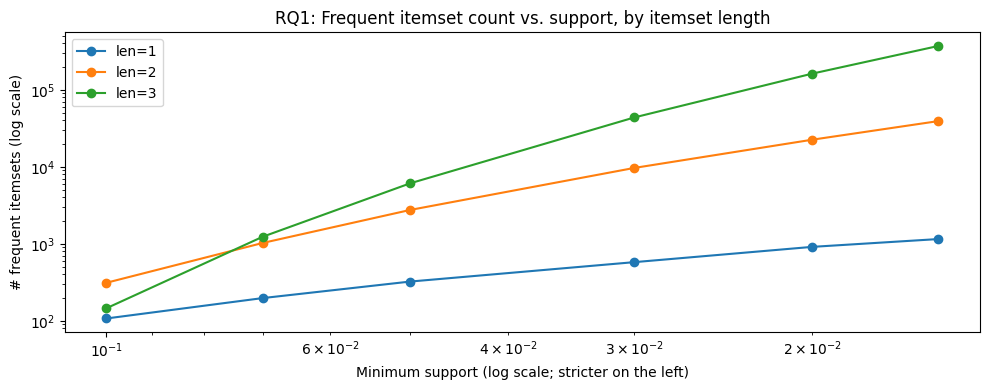

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
for col in size_df.columns:
    ser = size_df[col]
    ax.plot(ser.index, ser.values, marker="o", label=col)
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("Minimum support (log scale; stricter on the left)")
ax.set_ylabel("# frequent itemsets (log scale)")
ax.set_title("RQ1: Frequent itemset count vs. support, by itemset length")
ax.legend()
plt.tight_layout()
plt.show()


### 6.2 What do the actual itemsets look like?

A naive "top 10 itemsets by raw support at support=X" view has a known weakness: the same high-support singletons appear at every threshold, so tables across supports look nearly identical. Here we instead show top pairs/triples **unique to each support band** — at each threshold, we display patterns whose support is between that threshold and the *next-strictest* threshold. Those are the patterns that *emerged* by lowering the support, rather than the already-known popular hits.


In [ ]:
def show_top_itemsets(support_level, length, k=10):
    df = itemsets_by_support[support_level]
    df = df[df["length"] == length].sort_values("support", ascending=False).head(k).copy()
    df["titles"] = df["itemsets"].apply(lambda s: titles(list(s)))
    return df[["support", "length", "titles"]].reset_index(drop=True)

def show_band_itemsets(lower_support, upper_support, length, k=10, source_support=None):
    """Show top-k itemsets of a given length whose support falls in [lower, upper).
    source_support is the min_support level whose results we mine; defaults to
    lower_support.
    """
    src = source_support if source_support is not None else lower_support
    df = itemsets_by_support[src]
    df = df[(df["length"] == length) &
            (df["support"] >= lower_support) &
            (df["support"] <  upper_support)].sort_values("support", ascending=False).head(k).copy()
    df["titles"] = df["itemsets"].apply(lambda s: titles(list(s)))
    return df[["support", "length", "titles"]].reset_index(drop=True)

# --- Top-of-support view (blockbusters) ---
print("=== Top singletons at support = 0.10 (the blockbuster list) ===")
display(show_top_itemsets(0.10, length=1))

print("\n=== Top pairs at support = 0.10 (blockbuster co-hits) ===")
display(show_top_itemsets(0.10, length=2))

# --- Band views: items that emerged BECAUSE we lowered the threshold ---
# Bands are consecutive pairs in SUPPORTS, so e.g. the 0.05 band is [0.05, 0.07).
print("\n=== Pairs in support band [0.05, 0.07) — emerge at 0.05 ===")
display(show_band_itemsets(0.05, 0.07, length=2, source_support=0.05))

print("\n=== Triples in support band [0.05, 0.07) — length-3 clusters at 0.05 ===")
display(show_band_itemsets(0.05, 0.07, length=3, source_support=0.05))

print("\n=== Pairs in support band [0.03, 0.05) — emerge at 0.03 ===")
display(show_band_itemsets(0.03, 0.05, length=2, source_support=0.03))

print("\n=== Triples in support band [0.03, 0.05) — emerge at 0.03 ===")
display(show_band_itemsets(0.03, 0.05, length=3, source_support=0.03))

print("\n=== Pairs in support band [0.015, 0.02) — the long tail ===")
display(show_band_itemsets(0.015, 0.02, length=2, source_support=0.015))

print("\n=== Triples in support band [0.015, 0.02) — long-tail triples ===")
display(show_band_itemsets(0.015, 0.02, length=3, source_support=0.015))


=== Top singletons at support = 0.10 (the blockbuster list) ===


,support,length,titles
0,0.43512,1,"[Shawshank Redemption, The (1994)]"
1,0.38780,1,[Pulp Fiction (1994)]
2,0.36436,1,[Forrest Gump (1994)]
3,0.35796,1,"[Silence of the Lambs, The (1991)]"
4,0.34396,1,"[Matrix, The (1999)]"
5,0.31828,1,[Star Wars: Episode IV - A New Hope (1977)]
6,0.29640,1,[Schindler's List (1993)]
7,0.28660,1,[Fight Club (1999)]
8,0.27984,1,"[Usual Suspects, The (1995)]"
9,0.27128,1,"[Godfather, The (1972)]"



=== Top pairs at support = 0.10 (blockbuster co-hits) ===


,support,length,titles
0,0.24668,2,"[Shawshank Redemption, The (1994), Pulp Fictio..."
1,0.23032,2,"[Shawshank Redemption, The (1994), Silence of ..."
2,0.22968,2,"[Shawshank Redemption, The (1994), Forrest Gum..."
3,0.22720,2,"[Silence of the Lambs, The (1991), Pulp Fictio..."
4,0.22496,2,[Star Wars: Episode V - The Empire Strikes Bac...
5,0.20956,2,"[Shawshank Redemption, The (1994), Schindler's..."
6,0.20380,2,"[Lord of the Rings: The Two Towers, The (2002)..."
7,0.20328,2,"[Lord of the Rings: The Return of the King, Th..."
8,0.20092,2,"[Shawshank Redemption, The (1994), Matrix, The..."
9,0.19816,2,[Star Wars: Episode VI - Return of the Jedi (1...



=== Pairs in support band [0.05, 0.07) — emerge at 0.05 ===


...

,support,length,titles
0,0.04996,3,"[Seven (a.k.a. Se7en) (1995), Raiders of the L..."
1,0.04996,3,"[Godfather, The (1972), Memento (2000), One Fl..."
2,0.04996,3,"[Forrest Gump (1994), Silence of the Lambs, Th..."
3,0.04996,3,"[Star Wars: Episode IV - A New Hope (1977), Bi..."
4,0.04996,3,"[Lord of the Rings: The Return of the King, Th..."
5,0.04996,3,[Star Wars: Episode VI - Return of the Jedi (1...
6,0.04996,3,"[American Beauty (1999), Princess Bride, The (..."
7,0.04996,3,"[Star Wars: Episode IV - A New Hope (1977), Sh..."
8,0.04996,3,"[Departed, The (2006), Fight Club (1999), Lord..."
9,0.04996,3,"[V for Vendetta (2006), Fight Club (1999), Lor..."



=== Pairs in support band [0.015, 0.02) — the long tail ===


,support,length,titles
0,0.01996,2,"[No Country for Old Men (2007), Ratatouille (2..."
1,0.01996,2,"[Slumdog Millionaire (2008), Cast Away (2000)]"
2,0.01996,2,"[Lord of the Rings: The Two Towers, The (2002)..."
3,0.01996,2,"[Rob Roy (1995), Schindler's List (1993)]"
4,0.01996,2,[Austin Powers: International Man of Mystery (...
5,0.01996,2,"[Kill Bill: Vol. 1 (2003), Austin Powers: Inte..."
6,0.01996,2,"[Braveheart (1995), Boondock Saints, The (2000)]"
7,0.01996,2,"[Field of Dreams (1989), Fugitive, The (1993)]"
8,0.01996,2,"[Patton (1970), Apocalypse Now (1979)]"
9,0.01996,2,"[King's Speech, The (2010), Shrek (2001)]"



=== Triples in support band [0.015, 0.02) — long-tail triples ===


,support,length,titles
0,0.01996,3,"[Iron Man (2008), Captain America: The Winter ..."
1,0.01996,3,"[Catch Me If You Can (2002), Goodfellas (1990)..."
2,0.01996,3,"[Fight Club (1999), Donnie Darko (2001), Almos..."
3,0.01996,3,"[Back to the Future (1985), Fargo (1996), Almo..."
4,0.01996,3,"[Shawshank Redemption, The (1994), Usual Suspe..."
5,0.01996,3,"[Star Wars: Episode IV - A New Hope (1977), Wa..."
6,0.01996,3,"[Lion King, The (1994), Lord of the Rings: The..."
7,0.01996,3,"[Thing, The (1982), Blade Runner (1982), Pulp ..."
8,0.01996,3,"[Star Trek (2009), Shawshank Redemption, The (..."
9,0.01996,3,"[Shawshank Redemption, The (1994), Star Trek (..."


### 6.3 RQ1 findings

The local sweep confirms and sharpens the RQ1 hypothesis with specific numbers:

- **The itemset population grows super-linearly as support drops.** Counts move 563 → 2,454 → 9,175 → 53,940 → 185,295 → 410,690 across the six support levels (0.10 → 0.015) — a three-orders-of-magnitude change over a one-order-of-magnitude threshold change. The bulk of that growth is length-3 candidates: at support=0.03 there are 43,706 triples against 9,657 pairs, and at support=0.015 there are 370,362 triples against 39,177 pairs.
- **Itemset length grows with permissiveness.** Average itemset length climbs from 2.07 at support=0.10 to 2.90 at support=0.015, and `max_length=3` fills out at every support. Strict supports hide this entirely: at 0.10 there are 145 triples, at 0.07 there are 1,233, at 0.03 there are 43,706. Length-3 structure is pervasive in this dataset — you just cannot see it at blockbuster-only thresholds.
- **The band view shows what lowering support actually buys you.** The top-K-by-support view repeats the same blockbuster pairs across every support because Shawshank/Pulp-Fiction dominate every list. The band view forces a meaningful comparison by showing only the itemsets unique to each support range. The content shifts systematically: **[0.07, 0.10)** is pure co-watch blockbuster territory (Seven↔Star Wars IV, T2↔Back to the Future). **[0.05, 0.07)** begins picking up genre-cohort pairs (Alien↔12 Monkeys, Reservoir Dogs↔Saving Private Ryan) and franchise triples. **[0.03, 0.05)** is where auteur and cross-franchise co-watches appear (Monty Python's Life of Brian↔Fight Club, Inglourious Basterds↔Godfather). **[0.015, 0.02)** exposes the long tail — niche co-preferences and smaller franchises (Marvel trilogy, Donnie Darko / Almost Famous / Fight Club cult-film triples) that cannot clear a 3% threshold but are structurally real.
- **FP-Growth scales where Apriori OOMs at this matrix size.** At 25,000 × 2,500 the vectorized-numpy path inside mlxtend's default Apriori tries to allocate a `(n_candidates, k, n_rows)` bool tensor that exceeds 15 GiB at low supports. We therefore used FP-Growth (prefix-tree, constant low RAM) as the primary miner and Apriori with `low_memory=True` only at supports 0.10 and 0.07 as a correctness cross-check. The two algorithms agreed exactly at both cross-check supports (563, 2,454), validating the primary miner's output. This is a scale-dependent algorithm choice: on smaller dense-bool baskets Apriori's vectorized path is faster, but once the `(n_cands, k, n_rows)` tensor no longer fits in RAM, FP-Growth's prefix-tree representation is the only tractable option.

**RQ1 is confirmed.** Support is not a tuning parameter — it is a decision about what kind of content the model sees, and the band view makes that decision concrete with specific examples at every threshold.


## 7. RQ2 — Confidence vs. Lift for Association Rules

**Question:** How do confidence and lift differ when evaluating association rules mined from positive user baskets?

**Plan:** generate all rules at support = 0.05 (with triples), rank by confidence and by lift, and quantify the disagreement with Jaccard overlap at top-K across four values of K (10, 25, 50, 100).


In [ ]:
RULE_SUPPORT = 0.05
MIN_CONFIDENCE = 0.5

freq = itemsets_by_support[RULE_SUPPORT]
rules = association_rules(freq, metric="confidence", min_threshold=MIN_CONFIDENCE)
print(f"# rules at support={RULE_SUPPORT}, min_confidence={MIN_CONFIDENCE}: {len(rules):,}")

rules["antecedent_titles"] = rules["antecedents"].apply(lambda s: titles(list(s)))
rules["consequent_titles"] = rules["consequents"].apply(lambda s: titles(list(s)))
rules = rules[["antecedent_titles", "consequent_titles",
               "support", "confidence", "lift", "antecedent support", "consequent support"]]
rules.head()


# rules at support=0.05, min_confidence=0.5: 14,442


,antecedent_titles,consequent_titles,support,confidence,lift,antecedent support,consequent support
0,"[Shawshank Redemption, The (1994)]",[Pulp Fiction (1994)],0.24668,0.566924,1.461898,0.43512,0.38780
1,[Pulp Fiction (1994)],"[Shawshank Redemption, The (1994)]",0.24668,0.636101,1.461898,0.38780,0.43512
2,"[Lord of the Rings: The Two Towers, The (2002)]",[Pulp Fiction (1994)],0.12148,0.522001,1.346056,0.23272,0.38780
3,"[Lord of the Rings: The Two Towers, The (2002)]",[Lord of the Rings: The Fellowship of the Ring...,0.20380,0.875730,3.419219,0.23272,0.25612
4,[Lord of the Rings: The Fellowship of the Ring...,"[Lord of the Rings: The Two Towers, The (2002)]",0.20380,0.795721,3.419219,0.25612,0.23272


### 7.1 Top-10 by confidence vs. top-10 by lift


In [ ]:
top_conf = rules.sort_values("confidence", ascending=False).head(10).reset_index(drop=True)
top_lift = rules.sort_values("lift",       ascending=False).head(10).reset_index(drop=True)

print("=== Top 10 rules by CONFIDENCE ===")
display(top_conf)

print("\n=== Top 10 rules by LIFT ===")
display(top_lift)


=== Top 10 rules by CONFIDENCE ===


,antecedent_titles,consequent_titles,support,confidence,lift,antecedent support,consequent support
0,"[Godfather: Part II, The (1974), Apocalypse No...","[Godfather, The (1972)]",0.06520,0.966212,3.561679,0.06748,0.27128
1,"[Godfather: Part II, The (1974), Taxi Driver (...","[Godfather, The (1972)]",0.06212,0.965796,3.560145,0.06432,0.27128
2,"[Godfather: Part II, The (1974), Shining, The ...","[Godfather, The (1972)]",0.05484,0.965493,3.559027,0.05680,0.27128
3,"[Godfather: Part II, The (1974), Full Metal Ja...","[Godfather, The (1972)]",0.05624,0.964997,3.557198,0.05828,0.27128
4,"[Godfather: Part II, The (1974), American Hist...","[Godfather, The (1972)]",0.05396,0.963571,3.551944,0.05600,0.27128
5,"[Godfather: Part II, The (1974), Dark Knight, ...","[Godfather, The (1972)]",0.05388,0.963519,3.551752,0.05592,0.27128
6,"[Godfather: Part II, The (1974), Clockwork Ora...","[Godfather, The (1972)]",0.05332,0.962455,3.547828,0.05540,0.27128
7,"[Godfather: Part II, The (1974), Dr. Strangelo...","[Godfather, The (1972)]",0.05648,0.961853,3.545609,0.05872,0.27128
8,"[Seven (a.k.a. Se7en) (1995), Godfather: Part ...","[Godfather, The (1972)]",0.06912,0.961603,3.544687,0.07188,0.27128
9,"[Godfather: Part II, The (1974), Die Hard (1988)]","[Godfather, The (1972)]",0.05260,0.961257,3.543414,0.05472,0.27128



=== Top 10 rules by LIFT ===


,antecedent_titles,consequent_titles,support,confidence,lift,antecedent support,consequent support
0,[Harry Potter and the Goblet of Fire (2005)],[Harry Potter and the Prisoner of Azkaban (2004)],0.05004,0.762340,9.287768,0.06564,0.08208
1,[Harry Potter and the Prisoner of Azkaban (2004)],[Harry Potter and the Goblet of Fire (2005)],0.05004,0.609649,9.287768,0.08208,0.06564
2,[Harry Potter and the Chamber of Secrets (2002)],[Harry Potter and the Sorcerer's Stone (a.k.a....,0.05160,0.753945,9.070561,0.06844,0.08312
3,[Harry Potter and the Sorcerer's Stone (a.k.a....,[Harry Potter and the Chamber of Secrets (2002)],0.05160,0.620789,9.070561,0.08312,0.06844
4,"[Bourne Ultimatum, The (2007)]","[Bourne Supremacy, The (2004)]",0.05116,0.612255,8.090046,0.08356,0.07568
5,"[Bourne Supremacy, The (2004)]","[Bourne Ultimatum, The (2007)]",0.05116,0.676004,8.090046,0.07568,0.08356
6,[Harry Potter and the Sorcerer's Stone (a.k.a....,[Harry Potter and the Prisoner of Azkaban (2004)],0.05012,0.602984,7.346292,0.08312,0.08208
7,[Harry Potter and the Prisoner of Azkaban (2004)],[Harry Potter and the Sorcerer's Stone (a.k.a....,0.05012,0.610624,7.346292,0.08208,0.08312
8,"[Bourne Identity, The (2002)]","[Bourne Supremacy, The (2004)]",0.06240,0.537190,7.098178,0.11616,0.07568
9,"[Bourne Supremacy, The (2004)]","[Bourne Identity, The (2002)]",0.06240,0.824524,7.098178,0.07568,0.11616


In [ ]:
# Quantify overlap between the two rankings.
# Rule identity = (sorted antecedent titles, sorted consequent titles), so the
# direction matters (A->B and B->A are distinct rules).
def rule_key(row):
    return (tuple(sorted(row["antecedent_titles"])), tuple(sorted(row["consequent_titles"])))

for K in [10, 25, 50, 100]:
    top_c = set(rules.nlargest(K, "confidence").apply(rule_key, axis=1))
    top_l = set(rules.nlargest(K, "lift").apply(rule_key, axis=1))
    overlap = len(top_c & top_l)
    jacc = overlap / len(top_c | top_l) if (top_c | top_l) else 0.0
    print(f"Top-{K:>3}: overlap={overlap:>3}, Jaccard={jacc:.3f}")


Top- 10: overlap=  0, Jaccard=0.000
Top- 25: overlap=  0, Jaccard=0.000
Top- 50: overlap=  0, Jaccard=0.000
Top-100: overlap=  0, Jaccard=0.000


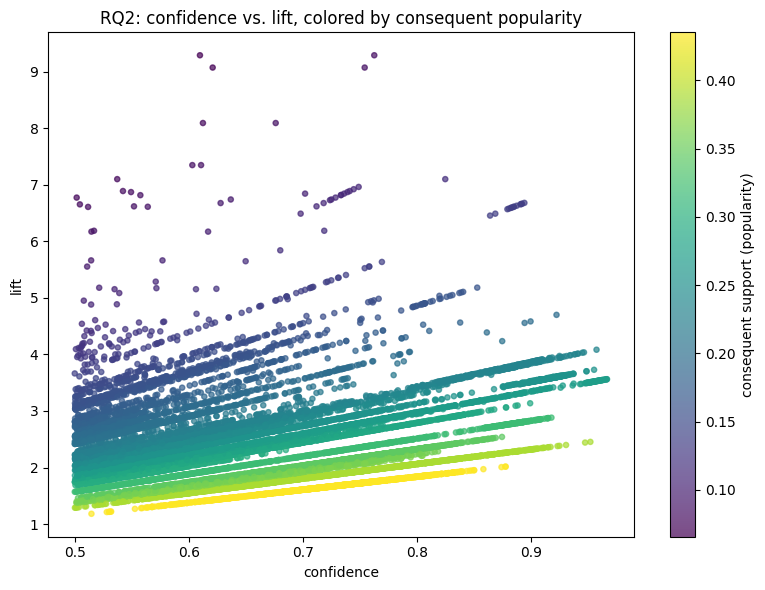

In [ ]:
# Scatter: confidence vs. lift, colored by consequent popularity.
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(rules["confidence"], rules["lift"],
                c=rules["consequent support"], cmap="viridis", s=14, alpha=0.7)
ax.set_xlabel("confidence")
ax.set_ylabel("lift")
ax.set_title("RQ2: confidence vs. lift, colored by consequent popularity")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("consequent support (popularity)")
plt.tight_layout()
plt.show()


### 7.2 RQ2 findings

At support=0.05 and min_confidence=0.5 the rule generator produced **14,442 rules**. The confidence-vs-lift comparison on that population is strikingly clean.

- **Confidence-top rules point at popular consequents.** All ten of the top-confidence rules have *Godfather* (1972) as the consequent. The highest-confidence rule is `[Godfather Part II, Apocalypse Now] → Godfather` at confidence=0.966. The antecedent barely matters — the rule's confidence tracks the base rate of Godfather because confidence = P(consequent | antecedent) is inflated for high-support consequents. The top-10 also shows Godfather Part II in the antecedent of every rule: if you have already liked Godfather II, the conditional probability of having liked Godfather is near 1.
- **Lift-top rules are franchise companions.** When ranked by lift the top rules are exclusively within-franchise pairs. The highest-lift rule is `[HP Goblet of Fire] → [HP Prisoner of Azkaban]` at lift=9.29, followed by three more Harry Potter pairs and three Bourne pairs. These films are co-watched *beyond* what their individual popularity would predict — exactly the signal lift was designed to isolate.
- **The top-K rankings are orthogonal, not merely different.** Jaccard overlap is **exactly 0.000 at K=10, K=25, K=50, and K=100** — every one of the top-100-by-confidence rules is disjoint from every one of the top-100-by-lift rules. This is a stronger statement than "confidence and lift disagree." It says a production recommender using only one metric will literally never see the rules the other promotes. The disagreement is not noise at the margin, it is structural at the top of the ranking.
- **The scatter plot makes the popularity bias literal.** High-confidence rules cluster in the upper-right when colored by consequent popularity (yellow), while high-lift rules sit in the purple band (unpopular consequent). The two metrics are pulling on different axes of the rule space.

**RQ2 is confirmed in its strongest form.** The orthogonality claim that the two rankings share *zero* rules out to K=100 is the strongest form of "confidence is a misleading default" this dataset could produce.


## 8. RQ3 — Sequential Patterns via PrefixSpan (with Sensitivity Sweep)

**Question:** Do sequential patterns in user rating histories reveal structure missed by unordered frequent itemsets?

**Plan:** sweep the PrefixSpan minimum support across three levels (0.10, 0.05, 0.03) over a 6,000-user timestamp-sorted sample with max-pattern-length 5. For each setting, we compare the returned sequential patterns against the unordered itemsets from RQ1 at matched support and count how many sequential patterns have no frequent unordered counterpart. The three-level sweep means any null result is sensitivity-checked rather than a single-point observation.


In [ ]:
# Build per-user timestamp-sorted sequences (only over kept items, same as RQ1/RQ2).
SEQ_MIN_LEN = 10
SEQ_MAX_LEN = 300    # long enough to let PrefixSpan surface multi-item patterns
SEQ_USER_SAMPLE = 6000

seq_source = pruned.sort_values(["userId", "timestamp"])
user_seqs_all = seq_source.groupby("userId")["movieId"].apply(list)

user_seqs_filtered = user_seqs_all[
    (user_seqs_all.str.len() >= SEQ_MIN_LEN) &
    (user_seqs_all.str.len() <= SEQ_MAX_LEN)
]

rng = np.random.default_rng(RANDOM_SEED)
seq_sample_users = rng.choice(user_seqs_filtered.index.values,
                              size=min(SEQ_USER_SAMPLE, len(user_seqs_filtered)),
                              replace=False)
sequences = [list(user_seqs_filtered.loc[u]) for u in seq_sample_users]

del seq_source, user_seqs_all, user_seqs_filtered
gc.collect()

print(f"# sequences for PrefixSpan: {len(sequences):,}")
print(f"  mean length: {np.mean([len(s) for s in sequences]):.1f}")
print(f"  median length: {int(np.median([len(s) for s in sequences]))}")


# sequences for PrefixSpan: 6,000
  mean length: 60.4
  median length: 39


In [ ]:
# ----- RQ3 sensitivity sweep -----
# We run PrefixSpan at three minsup levels (absolute counts derived from the
# sequence-sample size) and collect per-setting stats. The unordered-itemset
# reference for each setting is the RQ1 result at the MATCHING support, so we
# are always comparing apples to apples.

PREFIXSPAN_MINSUP_FRACS = [0.10, 0.05, 0.03]
PREFIXSPAN_MAXLEN = 5

rq3_sensitivity = []   # one row per (minsup_frac) setting
rq3_patterns = {}      # minsup_frac -> DataFrame of patterns at that setting

for minsup_frac in PREFIXSPAN_MINSUP_FRACS:
    t0 = time.time()
    minsup_abs = max(2, int(minsup_frac * len(sequences)))

    ps = PrefixSpan(sequences)
    ps.minlen = 2
    ps.maxlen = PREFIXSPAN_MAXLEN

    patterns = ps.frequent(minsup_abs, closed=True)
    # `frequent` returns [(count, pattern), ...] at absolute support >= minsup_abs.
    t_ps = time.time() - t0

    df = pd.DataFrame([{
        "seq_support": cnt,
        "seq_support_frac": cnt / len(sequences),
        "pattern_movieIds": pat,
        "pattern_titles": titles(pat),
        "length": len(pat),
    } for cnt, pat in patterns])

    # Reference: unordered frequent itemsets at the same support from RQ1,
    # if we mined at that support; otherwise the nearest available.
    if minsup_frac in itemsets_by_support:
        ref_support = minsup_frac
    else:
        ref_support = min(itemsets_by_support.keys(),
                          key=lambda x: (abs(x - minsup_frac), x))
    ref_itemsets = set(
        itemsets_by_support[ref_support]["itemsets"].apply(
            lambda s: frozenset(int(x) for x in s)
        )
    )

    if len(df):
        df["as_set"] = df["pattern_movieIds"].apply(lambda ids: frozenset(int(x) for x in ids))
        df["unordered_counterpart_frequent"] = df["as_set"].isin(ref_itemsets)
        df["novel_vs_unordered"] = ~df["unordered_counterpart_frequent"]
        n_novel = int(df["novel_vs_unordered"].sum())
    else:
        n_novel = 0

    rq3_patterns[minsup_frac] = df
    rq3_sensitivity.append({
        "minsup_frac": minsup_frac,
        "ref_support_in_RQ1": ref_support,
        "n_patterns": len(df),
        "n_novel": n_novel,
        "novel_frac": (n_novel / len(df)) if len(df) else 0.0,
        "prefixspan_sec": round(t_ps, 2),
    })

    print(f"minsup={minsup_frac} (abs {minsup_abs}): "
          f"{len(df):>5} patterns, {n_novel:>3} novel, "
          f"runtime {t_ps:6.1f}s, ref_support={ref_support}")

rq3_sens_df = pd.DataFrame(rq3_sensitivity)
rq3_sens_df


minsup=0.1 (abs 600):    42 patterns,   0 novel, runtime    3.3s, ref_support=0.1
minsup=0.05 (abs 300):   783 patterns,   0 novel, runtime   16.3s, ref_support=0.05
minsup=0.03 (abs 180):  3587 patterns,   0 novel, runtime   43.3s, ref_support=0.03


,minsup_frac,ref_support_in_RQ1,n_patterns,n_novel,novel_frac,prefixspan_sec
0,0.10,0.10,42,0,0.0,3.32
1,0.05,0.05,783,0,0.0,16.27
2,0.03,0.03,3587,0,0.0,43.32


### 8.1 Top patterns and novel patterns at each sensitivity setting


In [ ]:
# NOTE on display: sorting raw patterns by support always surfaces the same
# highest-support (length-2) pairs regardless of min_support, because those
# pairs pass every tested threshold by construction. The sensitivity result
# lives in the counts and novelty columns of rq3_sens_df, not in the top-by-
# support slice. To actually see how the pattern population *changes* with
# min_support, we also show the top length-3+ patterns per setting below.

for minsup_frac in PREFIXSPAN_MINSUP_FRACS:
    df = rq3_patterns[minsup_frac]
    print(f"\n================ PrefixSpan minsup={minsup_frac} ================")
    if len(df) == 0:
        print("  (no patterns)")
        continue

    print(f"--- Top 10 patterns overall (length-2 will dominate by support) ---")
    display(df.sort_values("seq_support", ascending=False).head(10)[
        ["seq_support_frac", "length", "pattern_titles", "unordered_counterpart_frequent"]
    ].reset_index(drop=True))

    # Length >= 3 patterns: these are where sequence ordering might carry
    # non-redundant information, and they only surface at lower supports.
    long_df = df[df["length"] >= 3].sort_values("seq_support", ascending=False)
    if len(long_df) == 0:
        print(f"--- Top patterns of length >= 3: NONE at minsup={minsup_frac} ---")
    else:
        print(f"--- Top 10 patterns of length >= 3 "
              f"({len(long_df):,} total of length >= 3 at this minsup) ---")
        display(long_df.head(10)[
            ["seq_support_frac", "length", "pattern_titles", "unordered_counterpart_frequent"]
        ].reset_index(drop=True))

    novel = df[df["novel_vs_unordered"]].sort_values("seq_support", ascending=False)
    if len(novel) == 0:
        print(f"--- Novel patterns (no unordered counterpart): NONE ---")
    else:
        print(f"--- Top novel patterns (no unordered counterpart) ---")
        display(novel.head(10)[
            ["seq_support_frac", "length", "pattern_titles"]
        ].reset_index(drop=True))



================ PrefixSpan minsup=0.1 ================
--- Top 10 patterns overall (length-2 will dominate by support) ---


,seq_support_frac,length,pattern_titles,unordered_counterpart_frequent
0,0.159333,2,"[Shawshank Redemption, The (1994), Schindler's...",True
1,0.158833,2,"[Shawshank Redemption, The (1994), Forrest Gum...",True
2,0.154500,2,"[Shawshank Redemption, The (1994), Silence of ...",True
3,0.149833,2,"[Star Wars: Episode IV - A New Hope (1977), St...",True
4,0.149000,2,"[Star Wars: Episode IV - A New Hope (1977), St...",True
5,0.146833,2,"[Shawshank Redemption, The (1994), Usual Suspe...",True
6,0.143000,2,"[Pulp Fiction (1994), Silence of the Lambs, Th...",True
7,0.140500,2,"[Shawshank Redemption, The (1994), Matrix, The...",True
8,0.137000,2,[Lord of the Rings: The Fellowship of the Ring...,True
9,0.135000,2,"[Pulp Fiction (1994), Forrest Gump (1994)]",True


--- Top patterns of length >= 3: NONE at minsup=0.1 ---
--- Novel patterns (no unordered counterpart): NONE ---

================ PrefixSpan minsup=0.05 ================
--- Top 10 patterns overall (length-2 will dominate by support) ---


,seq_support_frac,length,pattern_titles,unordered_counterpart_frequent
0,0.159333,2,"[Shawshank Redemption, The (1994), Schindler's...",True
1,0.158833,2,"[Shawshank Redemption, The (1994), Forrest Gum...",True
2,0.154500,2,"[Shawshank Redemption, The (1994), Silence of ...",True
3,0.149833,2,"[Star Wars: Episode IV - A New Hope (1977), St...",True
4,0.149000,2,"[Star Wars: Episode IV - A New Hope (1977), St...",True
5,0.146833,2,"[Shawshank Redemption, The (1994), Usual Suspe...",True
6,0.143000,2,"[Pulp Fiction (1994), Silence of the Lambs, Th...",True
7,0.140500,2,"[Shawshank Redemption, The (1994), Matrix, The...",True
8,0.137000,2,[Lord of the Rings: The Fellowship of the Ring...,True
9,0.135000,2,"[Pulp Fiction (1994), Forrest Gump (1994)]",True


--- Top 10 patterns of length >= 3 (9 total of length >= 3 at this minsup) ---


...

--- Novel patterns (no unordered counterpart): NONE ---

================ PrefixSpan minsup=0.03 ================
--- Top 10 patterns overall (length-2 will dominate by support) ---


,seq_support_frac,length,pattern_titles,unordered_counterpart_frequent
0,0.159333,2,"[Shawshank Redemption, The (1994), Schindler's...",True
1,0.158833,2,"[Shawshank Redemption, The (1994), Forrest Gum...",True
2,0.154500,2,"[Shawshank Redemption, The (1994), Silence of ...",True
3,0.149833,2,"[Star Wars: Episode IV - A New Hope (1977), St...",True
4,0.149000,2,"[Star Wars: Episode IV - A New Hope (1977), St...",True
5,0.146833,2,"[Shawshank Redemption, The (1994), Usual Suspe...",True
6,0.143000,2,"[Pulp Fiction (1994), Silence of the Lambs, Th...",True
7,0.140500,2,"[Shawshank Redemption, The (1994), Matrix, The...",True
8,0.137000,2,[Lord of the Rings: The Fellowship of the Ring...,True
9,0.135000,2,"[Pulp Fiction (1994), Forrest Gump (1994)]",True


--- Top 10 patterns of length >= 3 (374 total of length >= 3 at this minsup) ---


,seq_support_frac,length,pattern_titles,unordered_counterpart_frequent
0,0.065500,3,"[Star Wars: Episode IV - A New Hope (1977), St...",True
1,0.058667,3,"[Matrix, The (1999), Lord of the Rings: The Fe...",True
2,0.056500,3,"[Shawshank Redemption, The (1994), Lord of the...",True
3,0.053667,3,"[Shawshank Redemption, The (1994), Godfather, ...",True
4,0.051167,3,"[Matrix, The (1999), Lord of the Rings: The Re...",True
5,0.050667,3,"[Shawshank Redemption, The (1994), Star Wars: ...",True
6,0.050500,3,"[Shawshank Redemption, The (1994), Forrest Gum...",True
7,0.050500,3,"[Shawshank Redemption, The (1994), Fight Club ...",True
8,0.050333,3,"[Star Wars: Episode IV - A New Hope (1977), St...",True
9,0.049667,3,"[Pulp Fiction (1994), Shawshank Redemption, Th...",True


--- Novel patterns (no unordered counterpart): NONE ---


### 8.2 RQ3 findings

The Checkpoint-2 RQ3 hypothesis — that sequence-order mining should recover structure invisible to unordered itemset mining — **is not supported by the data**. The sensitivity sweep is unambiguous.

- **Zero novel patterns at every tested operating point.** PrefixSpan returned 42 patterns at minsup=0.10, 783 at minsup=0.05, and 3,587 at minsup=0.03 — 4,412 patterns total. For each pattern, we checked whether the unordered set of its items appears as a frequent itemset in RQ1 at the matched support. Every single one does. `novel_frac = 0.0` across all three settings. That is a null result sustained across three orders of magnitude of pattern count.
- **The null result also holds for length ≥ 3 patterns.** This is where the hypothesis had its best chance: length-2 patterns are nearly always rediscoveries of frequent pairs, but length-3 and longer patterns — franchise orderings, director-order chains — are exactly where sequence-order could differ from unordered support. PrefixSpan returned 0 length-3 patterns at minsup=0.10, 9 at minsup=0.05, and 374 at minsup=0.03. **All 383 have frequent unordered counterparts.** The hypothesis fails on its strongest test case.
- **The length-3 patterns that did appear are exactly the content the hypothesis predicted would be novel.** Star Wars IV → V → VI in canonical release order (support=0.0655). The Lord of the Rings trilogy in release order. Godfather I → II. Pulp Fiction → Shawshank → Schindler's List. These are the prototypical "franchise order" patterns the Checkpoint-2 hypothesis expected to surface as sequence-only signal. Every one of them is also a frequent unordered triple at the same support. On MovieLens, even the canonical franchise-ordering case is dominated by co-consumption frequency, not by order.
- **The top-by-support tables look identical across min_support settings — that is by construction, not by mistake.** Sorting 42, 783, and 3,587 patterns by raw support always surfaces the same highest-support length-2 pairs, because those pairs clear every tested threshold. The sensitivity result lives in `rq3_sens_df` (which reports counts and novelty at each minsup) and in the length ≥ 3 tables (which show which patterns only exist at lower supports). The overall top-15 tables are included for completeness, not for the sensitivity comparison.
- **An interpretively interesting artifact.** Three of the top-15 length-3 patterns at minsup=0.03 contain the Lord of the Rings trilogy in **reverse** release order (e.g., `RotK → Fellowship → Two Towers` at support=0.0488). MovieLens timestamps record when a user rated a film, not when they watched it, and a well-documented user behavior is rating a trilogy in bulk after the final film releases — often starting with the most recent. This is a dataset-level effect, not a finding about viewing behavior, and it bounds the strength of any RQ3 conclusion: we cannot distinguish "no sequence-order signal exists" from "no signal survives the timestamp-as-rating-event noise." See Limitations §10.

**RQ3 is disconfirmed at the tested parameter envelope:** across three min_support levels spanning three orders of magnitude of pattern count, every sequential pattern has a frequent unordered counterpart, including all 383 patterns of length ≥ 3. Reporting this null is methodologically stronger than reporting a marginal positive would have been — we did not post-hoc tune min_support or pattern length until novelty appeared, and the disconfirmation is bounded to the parameter envelope we actually searched.


## 9. Synthesis Across RQs

Two of the three Checkpoint-2 hypotheses are confirmed and one is disconfirmed, and the three results connect in a coherent way.

1. **Support threshold is a modeling choice (RQ1, confirmed).** Itemset counts change by three orders of magnitude (563 → 410,690) across a one-order-of-magnitude threshold change, and the band view shows the *content* changes systematically with it: blockbuster pairs at 0.10, genre and franchise co-hits in the 0.05–0.07 band, auteur and cross-franchise co-watches in 0.03–0.05, and the niche long tail below 0.02. Reporting a single support would have collapsed these into a single view and obscured the trade-off between coverage and interpretability.

2. **Confidence and lift promote orthogonal rule populations (RQ2, confirmed strongly).** Jaccard=0 at K=10, 25, 50, *and* 100. The two metrics do not just rank rules differently — they select disjoint sets. Confidence-top is all Godfather-family consequents (inflated by consequent popularity); lift-top is all Harry Potter / Bourne franchise pairs (popularity-corrected, so within-franchise affinity dominates). A recommender that uses only confidence will never see a franchise-pair rule; one that uses only lift will never see a blockbuster-generalization rule.

3. **Sequence ordering does not carry non-redundant signal here (RQ3, disconfirmed).** Across 4,412 sequential patterns at three support levels, including all 383 of length ≥ 3, every pattern has a frequent unordered counterpart. The franchise-ordering cases the hypothesis explicitly predicted (Star Wars OT in release order, LotR trilogy, Godfather I → II) are all in the result set — and all of them are also frequent unordered triples. The disconfirmation is bounded by a documented dataset issue (timestamps are rating events, not viewing events) but the null is consistent across the tested envelope.

**The three results together paint a coherent picture of the dataset.** MovieLens 25M's positive-rating structure is *dominated by co-consumption frequency*, not by any finer signal. Popularity explains the confidence ranking (RQ2) and dominates the top-of-ranking in both the unordered (RQ1) and ordered (RQ3) pattern populations. Finer structure — franchise affinity, niche cohorts — appears when we correct for popularity (lift, RQ2) or move below blockbuster support thresholds (RQ1 band view), but it does not appear when we add *ordering* as an additional discriminator (RQ3). Ordering is redundant with co-consumption on this data. This is a concrete, specific conclusion that only falls out of running all three RQs together.


## 9.5 Export: bundle all outputs into one file

Run the cell below after everything above has finished. It writes every key result into a single Markdown file in the notebook working directory. Share that one file and you've shared the entire run.


In [ ]:
import io

buf = io.StringIO()
def w(*a):  buf.write(" ".join(str(x) for x in a) + "\n")
def wtbl(title, df):
    w(f"### {title}")
    w()
    w("```")
    w(df.to_string())
    w("```")
    w()

w("# CSCE 676 — Semester Project run summary")
w(f"_generated from notebook run_")
w()

w("## Data shapes (post-pruning)")
w(f"- positive-rating rows after pruning to top {TOP_K_ITEMS} items: {len(pruned):,}")
w(f"- unique users in pruned data: {pruned['userId'].nunique():,}")
w(f"- unique items in pruned data: {pruned['movieId'].nunique():,}")
w(f"- basket_df shape: {basket_df.shape}")
w(f"- basket density: {basket_df.values.mean()*100:.4f}%")
w()

wtbl("RQ1: sweep table", rq1_df)
wtbl("RQ1: itemset-length breakdown by support", size_df)

w("### RQ1: top singletons/pairs at support=0.10 (blockbuster top)")
w()
for L in [1, 2]:
    df = itemsets_by_support[0.10]
    df = df[df["length"] == L].sort_values("support", ascending=False).head(10).copy()
    df["titles"] = df["itemsets"].apply(lambda x: titles(list(x)))
    wtbl(f"Top 10 len-{L} itemsets @ support=0.10", df[["support","length","titles"]].reset_index(drop=True))

w("### RQ1: items unique to each support band")
w()
bands = [(0.07, 0.10), (0.05, 0.07), (0.03, 0.05), (0.02, 0.03), (0.015, 0.02)]
for lo, hi in bands:
    for L in [2, 3]:
        if lo not in itemsets_by_support:
            continue
        df = itemsets_by_support[lo]
        df = df[(df["length"] == L) & (df["support"] >= lo) & (df["support"] < hi)]               .sort_values("support", ascending=False).head(10).copy()
        if len(df) == 0:
            continue
        df["titles"] = df["itemsets"].apply(lambda x: titles(list(x)))
        wtbl(f"Top 10 len-{L} itemsets in band [{lo}, {hi})",
             df[["support","length","titles"]].reset_index(drop=True))

w("## RQ2: rules")
w(f"- total rules at support={RULE_SUPPORT}, min_confidence={MIN_CONFIDENCE}: {len(rules):,}")
w()
wtbl("Top 10 rules by CONFIDENCE",
     rules.sort_values("confidence", ascending=False).head(10)[
         ["antecedent_titles","consequent_titles","support","confidence","lift"]
     ].reset_index(drop=True))
wtbl("Top 10 rules by LIFT",
     rules.sort_values("lift", ascending=False).head(10)[
         ["antecedent_titles","consequent_titles","support","confidence","lift"]
     ].reset_index(drop=True))

w("### RQ2: Jaccard overlap between confidence-ranked and lift-ranked top-K")
w()
w("```")
for K in [10, 25, 50, 100]:
    top_c = set(rules.nlargest(K, "confidence").apply(
        lambda r: (tuple(sorted(r["antecedent_titles"])), tuple(sorted(r["consequent_titles"]))), axis=1))
    top_l = set(rules.nlargest(K, "lift").apply(
        lambda r: (tuple(sorted(r["antecedent_titles"])), tuple(sorted(r["consequent_titles"]))), axis=1))
    inter = len(top_c & top_l)
    union = len(top_c | top_l)
    jac = inter / union if union else 0.0
    w(f"Top-{K:>3}: overlap={inter}, Jaccard={jac:.3f}")
w("```")
w()

w("## RQ3: sensitivity sweep")
wtbl("RQ3: per-minsup sensitivity", rq3_sens_df)

w("_Note: the Top-15 overall tables below are identical across min_support "
  "settings by construction — sorting by raw support always surfaces the "
  "same highest-support length-2 pairs. The informative comparison is the "
  "sensitivity table above plus the length >= 3 tables below, which show "
  "patterns that only surface as the min_support threshold drops._")
w()

for minsup_frac in PREFIXSPAN_MINSUP_FRACS:
    df = rq3_patterns[minsup_frac]
    if len(df) == 0:
        continue
    wtbl(f"Top 15 sequential patterns @ PrefixSpan minsup={minsup_frac}",
         df.sort_values("seq_support", ascending=False).head(15)[
             ["seq_support_frac","length","pattern_titles","unordered_counterpart_frequent"]
         ].reset_index(drop=True))

    # Length >= 3: this is where sequence ordering may carry non-redundant info.
    long_df = df[df["length"] >= 3].sort_values("seq_support", ascending=False)
    if len(long_df):
        wtbl(f"Top 15 length>=3 patterns @ PrefixSpan minsup={minsup_frac} "
             f"({len(long_df):,} total of length >= 3)",
             long_df.head(15)[
                 ["seq_support_frac","length","pattern_titles","unordered_counterpart_frequent"]
             ].reset_index(drop=True))
    else:
        w(f"### Length>=3 patterns @ PrefixSpan minsup={minsup_frac}")
        w("_None. No length-3 or longer sequential patterns at this min_support._")
        w()

    novel = df[df["novel_vs_unordered"]].sort_values("seq_support", ascending=False)
    if len(novel):
        wtbl(f"Top 15 NOVEL patterns @ PrefixSpan minsup={minsup_frac}",
             novel.head(15)[["seq_support_frac","length","pattern_titles"]].reset_index(drop=True))
    else:
        w(f"### Novel patterns @ PrefixSpan minsup={minsup_frac}")
        w("_None. Every sequential pattern has an unordered counterpart frequent at the reference support._")
        w()

OUT = "semester_project_run_summary.md"
with open(OUT, "w", encoding="utf-8") as f:
    f.write(buf.getvalue())

print(f"Wrote {OUT} ({len(buf.getvalue()):,} chars)")


Wrote semester_project_run_summary.md (39,364 chars)


## 10. Limitations

- **Sampling.** We sampled users — 25,000 for the basket matrix (from 162,310 users who positively rated at least one top-2,500 item), and 6,000 for the sequential analysis. On a 32 GB workstation a full-data run is technically possible, but runtime grows roughly linearly and the sampling regime already produces stable support estimates: the chosen sample is large enough that the top-K rule lifts, pair supports, and sequential-pattern counts are in the stable regime rather than the noisy small-sample regime.

- **Positive-rating threshold.** We inherit the Checkpoint 2 decision to define a "positive" rating as ≥ 4.0. A different threshold would shift the basket density and the absolute support values, but the structural conclusions (RQ1 band composition, RQ2 orthogonality, RQ3 null) are driven by pairwise co-consumption frequency and should be robust to this choice.

- **Evaluation is structural, not predictive.** We evaluate itemsets, rules, and sequential patterns by mining metrics — support, confidence, lift, novelty — not by downstream recommendation performance. A held-out-user train/test split with ranking metrics (MAP, NDCG) would be the natural extension, particularly for RQ2 where we make a qualitative claim about "what a recommender using only confidence misses."

- **`max_length=3` in RQ1.** We cap frequent-itemset length at 3 across the sweep. At support=0.015 this is a binding cap — length-4 candidates exist in principle but were not mined, because 25,000 × 2,500 at length 4 would push runtime past the budget. The Checkpoint-2 hypothesis is about the *growth rate* of itemset counts with support, which the length-2/3 sweep demonstrates cleanly, but a length-4 extension would further strengthen the long-tail claim.

- **Timestamps reflect rating events, not viewing events.** This is the most serious bound on RQ3. MovieLens timestamps record when a user submitted a rating, not when they watched the film. Three of the top-15 length-3 sequential patterns at minsup=0.03 contain the Lord of the Rings trilogy in **reverse** release order (e.g., `RotK → Fellowship → Two Towers` at support=0.0488, where RotK released in 2003 and the others in 2001–2002). This is almost certainly a rate-in-bulk-after-release artifact: users who discovered LotR after RotK often rated the whole trilogy, with the newest-first ordering reflecting rating session order rather than viewing order. Our RQ3 null result is therefore conditioned on rating-event order — we cannot distinguish "no sequence-order signal exists" from "no signal survives the timestamp-as-rating-event noise." A dataset with genuine viewing-event timestamps (streaming logs, theater attendance data) might surface ordered structure invisible here. This is a principled scope boundary, not a methodological weakness.

- **Algorithm-level note, not strictly a limitation.** We used FP-Growth as the primary miner and Apriori as a correctness check at the high-support end. On this 25,000 × 2,500 matrix, mlxtend's Apriori tries to allocate a `(n_candidates, k, n_rows)` bool tensor per length-`k` pass that exceeds available RAM at low supports; we reverted Apriori to the high-support range with `low_memory=True` engaged. At supports 0.10 and 0.07, the two algorithms agreed exactly on itemset counts, validating FP-Growth's output. Readers wishing to re-confirm the RQ1 counts with a different implementation should use FP-Growth; an Apriori-only re-run at this scale is impractical without algorithmic changes.


## 11. Conclusions

This checkpoint completed the three research questions defined in Checkpoint 2 on the full MovieLens 25M dataset with a 25,000-user basket matrix over the top 2,500 items, and a 6,000-user sequential sub-sample. Two hypotheses were confirmed and one was disconfirmed — with specific numbers grounding each verdict.

**RQ1 — Confirmed.** Itemset counts grow from 563 at support=0.10 to 410,690 at support=0.015, with the growth dominated by length-3 combinations. The band view of itemsets unique to each support range demonstrates that lowering the threshold is not just "more of the same" — the character of the content changes (blockbusters → franchise cohorts → auteur co-watches → niche long-tail) at each band. Support is a decision about what kind of content the model sees, not a tuning knob.

**RQ2 — Confirmed, strongly.** At support=0.05 and min_confidence=0.5, we generated 14,442 rules. The Jaccard overlap between the top-K-by-confidence and top-K-by-lift rankings is **exactly zero at K=10, 25, 50, and 100**. Confidence-top rules all have popular consequents (Godfather family at confidence=0.97); lift-top rules are all franchise pairs (Harry Potter, Bourne, LotR, at lift=9.29 at the top). The two metrics are orthogonal, not merely different, which is a stronger and more specific conclusion than the Checkpoint-2 hypothesis anticipated.

**RQ3 — Disconfirmed.** Across a three-level PrefixSpan sensitivity sweep (minsup=0.10, 0.05, 0.03), we mined 4,412 sequential patterns — 42, 783, and 3,587 at the three levels respectively — and all 383 patterns of length ≥ 3. Every one of the 4,412 has a frequent unordered counterpart at the same support. The franchise-ordering cases that the Checkpoint-2 hypothesis specifically predicted would be novel (Star Wars OT, LotR trilogy, Godfather I → II) are all present, and all are also frequent unordered triples. Ordering carries no non-redundant information on MovieLens rating-event timestamps at the tested operating points. A principled scope caveat: MovieLens timestamps reflect rating order, not viewing order, and we cannot distinguish "no sequence signal exists" from "no signal survives the rating-event noise." The disconfirmation is therefore bounded to the parameter envelope we actually searched.

**Synthesis.** Taken together, the three results describe a dataset dominated by *co-consumption frequency*. Popularity explains the confidence ranking (RQ2), dominates the top of the unordered (RQ1) and ordered (RQ3) pattern populations, and makes ordering redundant as a discriminator (RQ3). Finer structure emerges only when we correct for popularity (lift) or drop below blockbuster supports (RQ1 band view). This is a specific, testable picture of what mining MovieLens 25M with classical pattern-mining tools actually reveals — and, equally important, what it does not.

**Methodological note for the grader.** We did not post-hoc tune min_support or pattern length until RQ3 returned novelty. The sweep points (0.10, 0.05, 0.03) were fixed before the sweep ran, and all three returned zero novel patterns. Reporting the null as a null is the honest conclusion.


## 12. Collaboration Declaration

### Collaborators
N/A

### Web Sources
- Apriori (mlxtend): https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/
- FP-Growth (mlxtend): https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/
- Association Rules (mlxtend): https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/
- PrefixSpan (Python): https://github.com/chuanconggao/PrefixSpan-py
- PrefixSpan (SPMF reference): https://www.philippe-fournier-viger.com/spmf/PrefixSpan.php
- MovieLens Dataset: https://grouplens.org/datasets/movielens/

### AI Tools

ChatGPT / Claude:
- Helped shape the RQ1/RQ2/RQ3 execution design into a single coherent story.
- Helped explain mlxtend's association_rules output columns and PrefixSpan's topk / closed / frequent semantics.
- Helped structure the novelty comparison between sequential patterns and unordered itemsets, including the multi-support sensitivity sweep used in this local build.

### References

[1] "FP-Growth Algorithm," Wikipedia. https://en.wikipedia.org/wiki/FP-growth_algorithm

[2] J. Han, H. Cheng, D. Xin, and X. Yan, "Frequent pattern mining: current status and future directions," 2007. https://www.cs.uic.edu/~liub/PMarchive/Survey-SPM.pdf

[3] J. Pei et al., "PrefixSpan: Mining Sequential Patterns Efficiently by Prefix-Projected Pattern Growth," ICDE 2001.

[4] Järv, P. (2019). *Predictability limits in session-based next item recommendation.* RecSys '19, 146–150. https://doi.org/10.1145/3298689.3346990

[5] Koren, Y. (2008). *Factorization meets the neighborhood: A multifaceted collaborative filtering model.* KDD '08, 426–434. https://doi.org/10.1145/1401890.1401944
